In [1]:
import os
import torch
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

In [2]:
nnUNet_raw = "data/nnUNet_raw"
nnUNet_preprocessed = "data/nUNet_preprocessed"

os.environ["nnUNet_raw"] = nnUNet_raw
os.environ["nnUNet_preprocessed"] = nnUNet_preprocessed

In [22]:
import dis


def get_dataset_name(dataset_id):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [
        d for d in os.listdir(nnUNet_raw)
        if d.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, d))
    ]
    if len(dataset_name) != 1:
        raise RuntimeError(f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1")
    return dataset_name[0]

def get_features(image_paths, transforms, feature_extractor, device):
    features = []
    with torch.no_grad():
        for path in tqdm(image_paths):
            img = Image.open(path).convert('RGB')
            img_t = transforms(img).unsqueeze(0).to(device)
            feat = feature_extractor(img_t)
            features.append(feat.flatten().cpu().numpy())
    return np.array(features)

def compute_id(features, dataset_name, visualize=False, save_dir='results/analysis/dataset_complexity'):
    N = len(features)
    if N < 3: return "Need at least 3 images"
    
    # Find 2 nearest neighbors (k=3 because index 0 is the point itself)
    nbrs = NearestNeighbors(n_neighbors=3).fit(features)
    distances, _ = nbrs.kneighbors(features)
    
    # Compute mu = r2 / r1
    r1, r2 = distances[:, 1], distances[:, 2]
    mu = r2 / r1
    
    # Filter out any identical images (r1=0) to avoid division by zero
    mu = mu[np.isfinite(mu) & (mu > 1)]
    N_filtered = len(mu)
    
    # Empirical CDF: sort mu and compute percentiles
    mu_sorted = np.sort(mu)
    F_emp = np.arange(1, N_filtered + 1) / N_filtered
    
    # >>> CRITICAL FIX: Exclude the very last data point (F_emp=1) <<<
    x = np.log(mu_sorted[:-1]).reshape(-1, 1)
    y = -np.log(1 - F_emp[:-1]).reshape(-1, 1)
    
    # The slope is the Intrinsic Dimension
    model = LinearRegression(fit_intercept=False).fit(x, y)
    d = model.coef_[0][0]

    if visualize:
        plt.figure(figsize=(8, 5))
        plt.scatter(x, y, alpha=0.5, label='Data Points (Log Transformed)')
        
        # Generate points for the fitted line using the calculated slope 'd'
        # The line equation is simply y_pred = x * d
        x_plot = np.linspace(min(x), max(x), 100).reshape(-1, 1)
        y_plot = x_plot * d
        
        plt.plot(x_plot, y_plot, color='red', linestyle='--', 
                 linewidth=2, label=f'Fitted line (Slope/ID = {d:.2f})')
        
        # plt.title(f'TwoNN Intrinsic Dimension Estimation Plot - {dataset_name.split("_")[1]}')
        plt.title(f'{dataset_name.split("_")[1]}')
        plt.xlabel('ln(r2/r1)')
        plt.ylabel('-ln(1 - F_emp)')
        plt.legend()
        plt.grid(True)
        plt.ylim(0, 10)
        plt.xlim(0, 2.25)
        os.makedirs(save_dir, exist_ok=True)
        save_path = f'{save_dir}/{dataset_name}_id.png'
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()
        print(f"Saved to {save_path}")
        
    return d

In [33]:
# Load pretrained ResNet50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.to(device)
model.eval()

# Remove the final classification layer to get 2048-dim features
feature_extractor = torch.nn.Sequential(*(list(model.children())[:-1]))

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [36]:
for module in model.children():
    print(module.__class__.__name__)

Conv2d
BatchNorm2d
ReLU
MaxPool2d
Sequential
Sequential
Sequential
Sequential
AdaptiveAvgPool2d
Linear


100%|██████████| 700/700 [00:05<00:00, 136.10it/s]
/tmp/ipykernel_1070357/2252722422.py:34: RuntimeWarning: divide by zero encountered in divide
  mu = r2 / r1


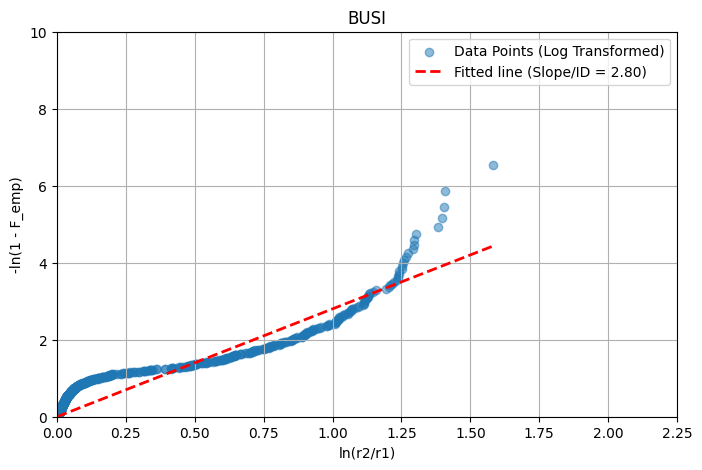

Saved to results/analysis/dataset_complexity/Dataset304_BUSI_id.png
Intrinsic Dimension: 2.80 - Dataset304_BUSI


In [28]:
dataset_id = 304
dataset_name = get_dataset_name(dataset_id)

imgs = glob(join(nnUNet_raw, dataset_name, "imagesTr", "*.png"))
# num_cases = 100
# imgs = imgs[:num_cases]
feats = get_features(imgs, transform, feature_extractor, device)

id = compute_id(feats, dataset_name, visualize=True)
print(f"Intrinsic Dimension: {id:.2f} - {dataset_name}")